# DID 方法与 Stata 实操

> 本附录配合第六章《双重差分法怎么选》使用。第六章正文讲方法选择的判断逻辑，本附录讲怎么落地：在同一份交错处理数据上跑通 2×2 基准、Bacon 分解的三单位手算、TWFE 诊断、`csdid` 的 group-time ATT、`drdid` 的 RA / IPW / 双重稳健对比，以及现代事件研究与敏感性分析。
>
> **运行环境**：Jupyter Notebook（`.ipynb`），可在 VS Code 中用 [nbstata](https://nbstata.readthedocs.io/) 内核执行，或通过 Stata-MCP 调用本地 Stata。习惯直接在 Stata 里操作的读者，用配套的 `A06_did_method_selection.do`（纯代码版）。
>
> **数据**：Bacon 手算模块用一份 3 个体 × 10 期的内置模拟数据（对应正文 Bacon 一节的最小例子）；其余模块用 `mpdta.dta`，Callaway–Sant'Anna 的美国县级最低工资面板，2500 obs、5 年（2003–2007）、三个处理批次（首次处理年份 2004/2006/2007）+ never-treated。全部**在线读取**，不占本地仓库。
>
> **与附录 G 的对称**：附录 G 用加州禁烟（单一处理组）演示反事实构造；本附录用 mpdta（交错处理）演示 DID 方法选择。两个附录合起来覆盖政策评估的两大典型数据结构。
>
> **稳健性设计**：核心命令（`csdid`、`drdid`）用官方文档的规范语法；版本敏感的命令（`eventstudyinteract`、`did_imputation`、`honestdid`）列为可选模块，用 `capture` 包裹，安装或语法失败不影响主线。


## 环境准备

首次运行安装外部命令。为避免课堂环境中断，安装用 `capture` 包裹、失败不报停。

In [1]:
clear all
set more off
version 17

* --- 基础依赖 ---
cap which ftools
if _rc ssc install ftools, replace
cap which reghdfe
if _rc ssc install reghdfe, replace

* --- DID 核心命令 ---
cap which drdid
if _rc ssc install drdid, replace        // csdid 的依赖，需先装
cap which csdid
if _rc ssc install csdid, replace
cap which bacondecomp
if _rc ssc install bacondecomp, replace

* --- 可选命令（版本敏感，失败不影响主线）---
cap which eventstudyinteract
if _rc cap ssc install eventstudyinteract, replace
cap which did_imputation
if _rc cap ssc install did_imputation, replace
cap which did2s
if _rc cap ssc install did2s, replace
* honestdid 通常需从 GitHub 安装，见 G.8


Running D:\stata19/profile.do ...


## 2×2 DID：四个均值与一个交互项

先用一份**内置模拟数据**把正文「2×2 DID」一节的四格均值验证一遍——不依赖外部链接，保证一定能跑通。真实数据 `mpdta` 从 G.3 开始用。

我们造一个两组两期的面板：真实政策效应设为 `+3`。看回归的交互项系数能否还原它，以及三个系数是否分别对应「组间水平差」「时间趋势」「双重差分」。

In [2]:
clear
set seed 20260708
set obs 200
gen id    = _n
gen treat = id > 100                       // 后 100 个为处理组
expand 2                                    // 每个单位两期
bysort id: gen post = _n - 1                // 0=政策前, 1=政策后

* DGP: 个体基线 + 时间趋势 + 政策效应(仅处理组×政策后)
gen y = 10 + 2*treat + 4*post + 3*(treat*post) + rnormal(0,1)
*        C0     θ1        θ2        γ=政策效应

* 四个组别-时期均值
table post treat, stat(mean y) nformat(%6.2f)

* DID 回归：交互项系数应还原 γ≈3
reg y i.treat##i.post, vce(robust)

Number of observations (_N) was 0, now 200.
(200 observations created)

--------------------------------
        |          treat        
        |      0       1   Total
--------+-----------------------
post    |                       
  0     |  10.06   12.02   11.04
  1     |  13.82   19.03   16.43
  Total |  11.94   15.52   13.73
--------------------------------

Linear regression                               Number of obs     =        400
                                                F(3, 396)         =    1504.88
                                                Prob > F          =     0.0000
                                                R-squared         =     0.9187
                                                Root MSE          =     .99722

------------------------------------------------------------------------------
             |               Robust
           y | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+--------------------------

**输出怎么读**：

- `table` 给出四个格子的均值，对应正文的 $C_0, Y_0, C_1, Y_1$。可以手算验证 $\gamma=(Y_1-Y_0)-(C_1-C_0)\approx 3$。
- 回归里 `1.treat` 是 $\theta_1$（政策前组间水平差，≈2），`1.post` 是 $\theta_2$（控制组时间趋势，≈4），`1.treat#1.post` 是 $\gamma$（双重差分，≈3）。
- 关键教学点：交互项才是政策效应，它把「处理组前后变化」里那部分本会自然发生的时间趋势（由控制组度量）扣掉了。

正文用 Card and Krueger (1994) 的新泽西—宾夕法尼亚最低工资作为这个结构的经典实证例子；这里用模拟数据是为了让每个人都能一键复现四格均值。

## Bacon 分解：三单位最小例子与权重手算

这个模块复现正文「权重怎么定：手算一遍」的全部数字。数据就是正文的最小例子：3 个体 × 10 期，$id=1$ 从不处理，$id=2$ 在 $t=5$ 进入（效应 2），$id=3$ 在 $t=8$ 进入（效应 4），处理吸收、含共同时间趋势。目标：亲眼看到 TWFE 系数 2.91 如何被拆成三块 2×2、再按权重拼回来。


Number of observations (_N) was 0, now 3.
(27 observations created)

Panel variable: id (strongly balanced)
 Time variable: t, 1 to 10
         Delta: 1 unit

      Source |       SS           df       MS      Number of obs   =        30
-------------+----------------------------------   F(12, 17)       =     72.18
       Model |  192.693182        12  16.0577652   Prob > F        =    0.0000
    Residual |  3.78181818        17  .222459893   R-squared       =    0.9808
-------------+----------------------------------   Adj R-squared   =    0.9672
       Total |     196.475        29       6.775   Root MSE        =    .47166

------------------------------------------------------------------------------
           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           D |      2.909      0.318     9.15   0.000        2.238       3.580
             |
          id |
          2  |      

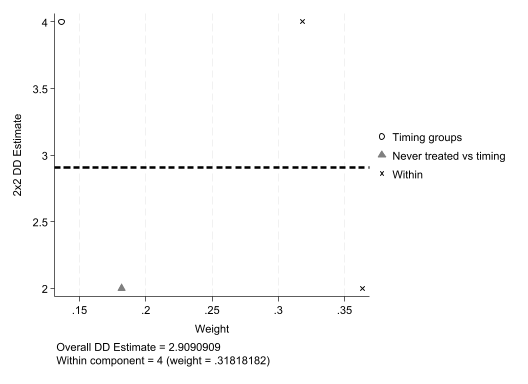

In [3]:
clear
set obs 3
gen id = _n
expand 10
bysort id: gen t = _n
xtset id t

* 吸收性处理：id=2 自 t=5 起，id=3 自 t=8 起
gen D = (id==2 & t>=5) | (id==3 & t>=8)

* 结果 = 个体基线 + 共同时间趋势 + 恒定处理效应(2 与 4)
gen y = 2*id + 0.1*t + cond(id==2, 2, cond(id==3, 4, 0))*D

* TWFE：交错处理下的混合系数
reg y D i.id i.t

* Bacon 分解：ddetail 给出每个 2×2 的估计值与权重
capture noisily bacondecomp y D, ddetail
if _rc di as error "bacondecomp 未运行成功，help bacondecomp 核对语法。"


**手算对账**（对应正文公式与数字；本例数据无噪声，回归完美拟合，标准误无意义，只看点估计与权重）：

- `bacondecomp` 把 TWFE 系数拆成三类 2×2：**早 vs 晚的未处理期**（估计值 2，权重 0.182）、**晚 vs 早的已处理期**（估计值 4，权重 0.136——这是坏比较）、**各处理组 vs 从不处理组**（合并估计值 2.93，权重 0.682）。三块权重之和恰为 1。
- 加权平均：$2.93\times0.682+2\times0.182+4\times0.136=2.91$，与 TWFE 直接跑出的系数分毫不差——TWFE 不是一个单一比较，而是这些 2×2 的加权平均。
- 权重排序由正文公式 $s_k\propto n_k(1-n_k)\times\bar D_k(1-\bar D_k)$ 决定：早处理组 $\bar D=6/10$、晚处理组 $\bar D=3/10$，处理时点越居中、处理方差越大、权重越高。**居中进入的组恰是坏比较的高发区，却拿到更高权重**——这就是 TWFE「错在权重」的机械根源。
- 本例效应同质（各组效应恒定），坏比较尚未惹祸；正文「异质效应下，负权重让符号翻转」一节展示了同一机械在异质效应下如何把总系数拖成负数。

**对口文献（含复现资料）**

- Goodman-Bacon, A. (2021). Difference-in-differences with variation in treatment timing. *Journal of Econometrics*, 225(2), 254–277. 配套 Stata 命令 `bacondecomp`。本模块示例编译自 Asjad Naqvi 的 [Bacon decomposition 教学页](https://asjadnaqvi.github.io/DiD/docs/code/06_02_bacon/)，中文详解见康希 ([2024](https://www.lianxh.cn/details/1347.html)）。


## 数据与处理时点结构

现在载入真实的交错处理数据 `mpdta`。先不估计任何模型，只看清处理时点的结构——这一步决定了后面能用哪些方法。

In [4]:
use https://friosavila.github.io/playingwithstata/drdid/mpdta.dta, clear

describe
* 关键变量：countyreal(县) year(年) lemp(就业,结果) lpop(人口,协变量)
*           first_treat(首次处理年份, 0=never-treated)

* 处理时点结构：看每个 first_treat 批次各有多少县
tab year first_treat

* 构造"当期是否处于处理中"的状态变量(供 TWFE 用)
gen treated = (first_treat > 0) & (year >= first_treat)
tab year treated
xtset countyreal year

(Written by R.              )

Contains data from https://friosavila.github.io/playingwithstata/drdid/mpdta.dt
> a
 Observations:         2,500                  Written by R.              
    Variables:             6                  17 May 2021 11:45
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
year            int     %9.0g                 year
countyreal      long    %9.0g                 countyreal
lpop            double  %9.0g                 lpop
lemp            double  %9.0g                 lemp
first_treat     int     %9.0g                 first.treat
treat           byte    %9.0g                 treat
-------------------------------------------------------------------------------
Sorted by: 

           |                 first.treat
      year |         0       20

**输出怎么读**：`tab year first_treat` 是最关键的一张表。它会显示：`first_treat` 取 0（never-treated，309 个县）、2004、2006、2007 四种值，且不同批次在不同年份进入政策。这三点确认了：

1. **存在 never-treated**（`first_treat==0`）——有干净的长期对照组；
2. **处理是分批的**（2004/2006/2007）——这不是 2×2，而是交错处理；
3. **处理是吸收性的**（一旦处理就保持）——适合 `csdid`、不需要 `did_multiplegt_dyn`。

注意区分两个变量：`first_treat` 是**首次处理年份**（时间不变，csdid 的 `gvar`），`treated` 是**当期处理状态**（随时间变，TWFE 的 $D_{it}$）。混淆这两个是初学者最常见的错误。

## TWFE 基准与 Bacon 分解诊断

先跑一个熟悉的 TWFE，作为**基准**（不是最终答案）。再用 Bacon 分解诊断这个系数背后混了哪些 2×2 比较。

(MWFE estimator converged in 2 iterations)
note: lpop is probably collinear with the fixed effects (all partialled-out val
> ues are close to zero; tol = 1.0e-09)

HDFE Linear regression                            Number of obs   =      2,500
Absorbing 2 HDFE groups                           F(   1,    499) =       7.59
Statistics robust to heteroskedasticity           Prob > F        =     0.0061
                                                  R-squared       =     0.9932
                                                  Adj R-squared   =     0.9915
                                                  Within R-sq.    =     0.0042
Number of clusters (countyreal) =        500      Root MSE        =     0.1391

                           (Std. err. adjusted for 500 clusters in countyreal)
------------------------------------------------------------------------------
             |               Robust
        lemp | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
---------

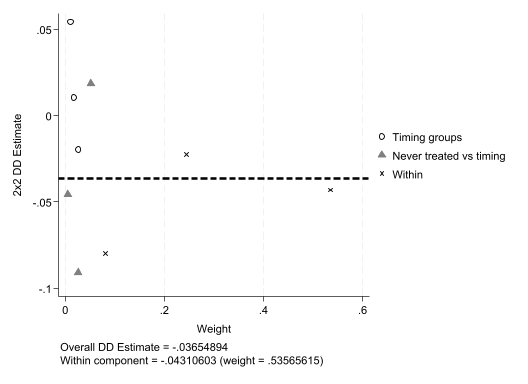

In [5]:
* TWFE 基准
reghdfe lemp treated lpop, absorb(countyreal year) vce(cluster countyreal)
estimates store twfe

* Bacon 分解：把 TWFE 系数拆成若干 2x2 DID 的加权平均
capture noisily bacondecomp lemp treated, ddetail
if _rc di as error "bacondecomp 未运行成功，可 help bacondecomp 核对语法或数据要求。"


**输出怎么读**：

- TWFE 的 `treated` 系数是一个数，它把 2004、2006、2007 三个批次、所有时期的比较压成了一个平均。
- `bacondecomp` 的输出把这个系数拆开，按比较类型分组报告权重和平均效应，典型分为三类：**Treated vs Never-treated**、**Earlier vs Later treated**（早处理组当对照，干净）、**Later vs Earlier treated**（晚处理组拿早已处理组当对照，**这是坏比较**）。
- 重点看「Later vs Earlier treated」那一类的权重有多大：权重越大，TWFE 被 already-treated 污染越严重。这就是为什么要转向 `csdid`。上一模块的三单位手算已经展示了这套分解的全部机械；这里是它在真实数据上的规模化版本。

Bacon 分解不修正 TWFE，它只诊断。修正靠下一节的 group-time ATT。

## `csdid`：估计 ATT(g,t) 再聚合

这是本附录的核心。`csdid` 的规范工作流是**两步**：先估计所有 group-time ATT，再用 `estat` 按需聚合。这个「先拆分、再聚合」的两步式，正好对应正文「加总的原则」一节的核心判断——聚合口径就是目标参数。

(Written by R.              )
............
Difference-in-difference with Multiple Time Periods

                                                         Number of obs = 2,500
Outcome model  : least squares
Treatment model: inverse probability
------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
g2004        |
 t_2003_2004 |     -0.015      0.022    -0.66   0.511       -0.058       0.029
 t_2003_2005 |     -0.076      0.029    -2.67   0.008       -0.133      -0.020
 t_2003_2006 |     -0.140      0.035    -3.97   0.000       -0.210      -0.071
 t_2003_2007 |     -0.107      0.033    -3.25   0.001       -0.171      -0.042
-------------+----------------------------------------------------------------
g2006        |
 t_2003_2004 |     -0.000      0.022    -0.02   0.983       -0.044       0.043
 t_2004_2005 |  

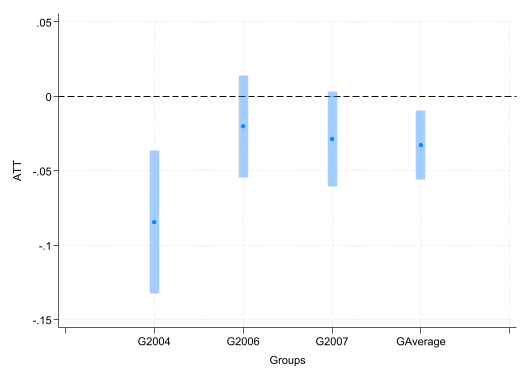

In [8]:
use https://friosavila.github.io/playingwithstata/drdid/mpdta.dta, clear

* 第一步：估计所有 ATT(g,t)，用 never-treated 作对照，双重稳健 IPW
csdid lemp lpop, ivar(countyreal) time(year) gvar(first_treat) method(dripw)

* 第二步：按不同目标参数聚合(postestimation)
estat simple      // 总体 ATT(按组规模加权，非等权)
estat event       // 动态 ATT：处理后第 k 年的效应
estat calendar    // 日历年 ATT
estat group       // 分组 ATT：各批次的效应

* 事件研究图
csdid_plot

**命令逐项解读**：

- `gvar(first_treat)`：**首次处理年份**，不是处理状态。`gvar==0` 被识别为 never-treated。这是 `csdid` 与 TWFE 最大的语法差异。
- `method(dripw)`：双重稳健 IPW（结果回归 + 倾向得分）。其他可选 `dripw`/`drimp`/`reg`/`ipw`/`stdipw`。
- `lpop` 放在 `indepvars` 位置：进入结果回归和倾向得分模型，让平行趋势在**条件**意义上更可信。
- 第二步的 `estat`：`simple`/`event`/`calendar`/`group` 各回答一个不同问题（见正文 @tbl-cipolicy-did-agg）。

**输出怎么读**：`estat simple` 是一个总体数，注意它是**按组规模加权**的平均，不是把所有 ATT(g,t) 等权平均——这是学生最容易误解的点。`estat event` 给出一列按相对处理时间排列的系数，负的相对期用来看政策前趋势，正的相对期是动态效应。

**never-treated vs not-yet-treated 对照组**

默认用 never-treated 作对照。加 `notyet` 选项改用「尚未处理」的单位作对照——当 never-treated 组很小、或担心它系统性不同于处理组时有用。

............
Difference-in-difference with Multiple Time Periods

                                                         Number of obs = 2,500
Outcome model  : least squares
Treatment model: inverse probability
------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
g2004        |
 t_2003_2004 |     -0.021      0.022    -0.98   0.328       -0.064       0.021
 t_2003_2005 |     -0.082      0.028    -2.88   0.004       -0.137      -0.026
 t_2003_2006 |     -0.138      0.034    -4.04   0.000       -0.205      -0.071
 t_2003_2007 |     -0.107      0.033    -3.25   0.001       -0.171      -0.042
-------------+----------------------------------------------------------------
g2006        |
 t_2003_2004 |     -0.007      0.022    -0.34   0.733       -0.050       0.035
 t_2004_2005 |     -0.005      0.018    -0.25 

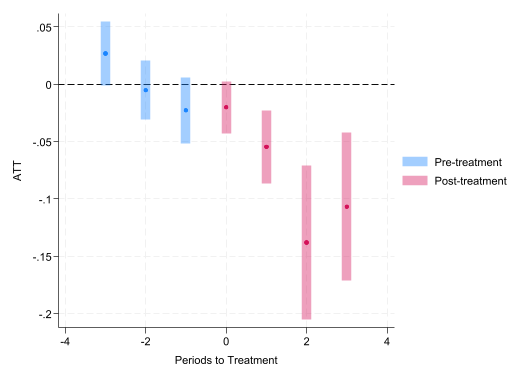

In [7]:
* 改用 not-yet-treated 作对照组
csdid lemp lpop, ivar(countyreal) time(year) gvar(first_treat) ///
      method(dripw) notyet
estat event

* 事件研究图
csdid_plot

**怎么选对照组**：never-treated 是最干净的（它永远不进政策）；但如果 never-treated 太少或与处理组差异大，not-yet-treated 提供更多可比单位（代价是它们未来会进政策，需假设「进政策前的路径」可比）。关键红线始终是：**绝不能把已经处理的单位当作无政策反事实**——`csdid` 无论用哪种对照，都自动守住了这条线。

**对口文献（含复现资料）**

- Callaway, B., & Sant'Anna, P. H. C. (2021). Difference-in-differences with multiple time periods. *Journal of Econometrics*, 225(2), 200–230. 这是 $ATT(g,t)$ 框架的原始文献，本附录用的 `mpdta` 数据就来自其配套 R 包 `did`（<https://bcallaway11.github.io/did/>），R 与 Stata 结果可对照复现。读者写交错处理 DID 论文时，可直接以该文的估计与作图流程为范本。


## `drdid`：RA、IPW 与双重稳健的两期对比

`drdid` 针对**两期** DID，演示双重稳健的核心思想：把正文的 RA、IPW、AIPW 三式在同一份 2×2 子样本上各估一遍，直接观察三个估计值的异同。为用同一份在线数据，把 `mpdta` 压成一个 2×2 子样本：只留 2004 年首次处理的县和 never-treated 县，只留 2003、2004 两年。

In [9]:
use https://friosavila.github.io/playingwithstata/drdid/mpdta.dta, clear

* 压成 2×2：2004 处理组 vs never-treated，2003(前) vs 2004(后)
keep if first_treat == 2004 | first_treat == 0
keep if inlist(year, 2003, 2004)

* mpdta 自带 treat 变量(标记 eventually-treated)，先删除以免歧义，再按本例定义重建
drop treat
gen treat = (first_treat == 2004)          // 单位级、时间不变
tab year treat

* 普通 DID 基准
reg lemp i.treat##i.year lpop, vce(cluster countyreal)

* 对应正文三式，逐一估计
drdid lemp lpop, ivar(countyreal) time(year) tr(treat) reg     // RA：只用结果模型
drdid lemp lpop, ivar(countyreal) time(year) tr(treat) ipw     // IPW：只用倾向得分
drdid lemp lpop, ivar(countyreal) time(year) tr(treat) dripw   // 双重稳健 IPW


(Written by R.              )
(855 observations deleted)
(987 observations deleted)

           |         treat
      year |         0          1 |     Total
-----------+----------------------+----------
      2003 |       309         20 |       329 
      2004 |       309         20 |       329 
-----------+----------------------+----------
     Total |       618         40 |       658 

Linear regression                               Number of obs     =        658
                                                F(4, 328)         =     649.86
                                                Prob > F          =     0.0000
                                                R-squared         =     0.8645
                                                Root MSE          =      .5509

                           (Std. err. adjusted for 329 clusters in countyreal)
------------------------------------------------------------------------------
             |               Robust
        lemp | Coe

**命令逐项解读**：

- `tr(treat)`：处理组指示，单位级、时间不变（「这个县是否属于 2004 处理批次」）。
- `ivar()` `time()`：面板与时间标识；`drdid` 用它们先做单位内一阶差分，再重加权。
- `lpop`：同时进入结果回归和倾向得分。

**三个估计值怎么对比**：`reg`、`ipw`、`dripw` 分别对应正文的 RA、IPW、AIPW 三式。三个 ATT 彼此接近，说明结果模型与倾向得分模型都不算离谱；若差异明显，则至少有一个模型误设——这正是双重稳健的用武之地：AIPW 只要两者之一正确即一致。

**双重稳健的含义**：`drdid` 同时估计「结果如何依赖协变量」和「谁更可能进处理」两个模型。**只要两者之一设定正确，ATT 就一致**——给了你两次做对的机会。这正是通向第七章的引子：当协变量很多、这两个模型的函数形式未知时，如何估计它们而不让第一阶段误差污染 ATT？那是 DDML 的问题。

若 `drdid` 报语法错误，先 `help drdid` 核对当前版本（该命令跨版本略有差异）。

**对口文献（含复现资料）**

- Sant'Anna, P. H. C., & Zhao, J. (2020). Doubly robust difference-in-differences estimators. *Journal of Econometrics*, 219(1), 101–122. 双重稳健 DID 的原始文献，公开了 R 包 `DRDID` 与复现代码（<https://github.com/pedrohcgs/DRDID>），其实证示例用 LaLonde/NSW 就业培训数据演示「结果回归 + 倾向得分，其一正确即一致」。想在条件平行趋势下做 DID 的读者，可照该示例组织协变量与稳健性。


## 现代事件研究修正（可选模块）

传统 TWFE 事件研究在交错处理下，lead/lag 系数可能被其他队列的处理效应污染。这里给 Sun–Abraham（`eventstudyinteract`）和 BJS（`did_imputation`）两个入口，并附 `did2s` 两步法的最小示例。两者版本敏感，用 `capture` 包裹，失败不影响前面主线。

In [10]:
use https://friosavila.github.io/playingwithstata/drdid/mpdta.dta, clear

gen never   = (first_treat == 0)
gen treated = (first_treat > 0) & (year >= first_treat)
gen rel   = year - first_treat if first_treat > 0   // 相对处理时间

* 构造 lead/lag 虚拟变量(排除基准期 rel=-1)
forvalues k = -3/3 {
    local nm = cond(`k'<0, "m"+string(abs(`k')), "p"+string(`k'))
    gen g_`nm' = (rel == `k')
    replace g_`nm' = 0 if missing(rel)
}
drop g_m1                                    // 基准期归一化

* 传统 TWFE 事件研究(作对照)
reghdfe lemp g_m3 g_m2 g_p0 g_p1 g_p2 g_p3 lpop, ///
    absorb(countyreal year) vce(cluster countyreal)

* Sun-Abraham：按队列估事件效应，避免污染(可选)
capture noisily eventstudyinteract lemp g_m3 g_m2 g_p0 g_p1 g_p2 g_p3, ///
    cohort(first_treat) control_cohort(never) ///
    absorb(countyreal year) vce(cluster countyreal)
if _rc di as error "eventstudyinteract 未运行成功，help eventstudyinteract 核对语法。"

* BJS 插补法(可选)：参数顺序为 Y i t Ei
capture noisily did_imputation lemp countyreal year first_treat, ///
    horizons(0/3) pretrends(3) fe(countyreal year) controls(lpop) cluster(countyreal)
if _rc di as error "did_imputation 未运行成功，help did_imputation 核对语法。"


* did2s 两步法(可选)：第一步只用固定效应净化结果，第二步在净化后的结果上估事件效应
capture noisily did2s lemp, first_stage(i.countyreal i.year) ///
    second_stage(g_m3 g_m2 g_p0 g_p1 g_p2 g_p3) treatment(treated) cluster(countyreal)
if _rc di as error "did2s 未运行成功，help did2s 核对语法。"


(Written by R.              )
(1,545 missing values generated)
(0 real changes made)
(0 real changes made)
(0 real changes made)
(0 real changes made)
(0 real changes made)
(0 real changes made)
(0 real changes made)
(MWFE estimator converged in 2 iterations)
note: lpop is probably collinear with the fixed effects (all partialled-out val
> ues are close to zero; tol = 1.0e-09)

HDFE Linear regression                            Number of obs   =      2,500
Absorbing 2 HDFE groups                           F(   6,    499) =       4.08
Statistics robust to heteroskedasticity           Prob > F        =     0.0005
                                                  R-squared       =     0.9933
                                                  Adj R-squared   =     0.9915
                                                  Within R-sq.    =     0.0103
Number of clusters (countyreal) =        500      Root MSE        =     0.1388

                           (Std. err. adjusted for 500 clusters i

**四种事件研究的区别**：

- **传统 TWFE**（第一段）：直观，但交错处理下 lead/lag 可能被其他队列污染，只作对照。
- **Sun–Abraham**（`eventstudyinteract`）：按处理队列（cohort）分别估事件时间效应再加权，`control_cohort()` 指定干净对照（这里用 never-treated）。
- **BJS**（`did_imputation`）：只用未处理观测拟合 $\alpha_i+\lambda_t$，插补每个处理观测的 $Y(0)$，再由实际值减插补值得到效应。参数顺序是 `Y i t Ei`（结果、单位、时间、首次处理年份）。

- **did2s**（Gardner 2022）：第一阶段只用固定效应和协变量解释结果、不含处理项，第二阶段用净化后的结果估事件效应——两步式避免处理效应污染固定效应估计。

四者目标参数和加权不同，结果**方向应一致、数值不必相同**。若都指向同一结论，说明结论不依赖单一估计量——这正是正文「证据架构」一节的实操体现。

**对口文献（含复现资料）**

* Sun, L., & Abraham, S. (2021). Estimating dynamic treatment effects in event studies with heterogeneous treatment effects. *Journal of Econometrics*, 225(2), 175–199. [Link](https://doi.org/10.1016/j.jeconom.2020.09.006), [PDF](https://lsun20.github.io/event_studies_paper.pdf), [Google](https://scholar.google.com/scholar?q=Estimating+dynamic+treatment+effects+in+event+studies+with+heterogeneous+treatment+effects). 事件研究污染问题的原始文献，配套 Stata 命令 `eventstudyinteract`，复现材料见 [Code](https://github.com/lsun20/EventStudyInteract)。

* Borusyak, K., Jaravel, X., & Spiess, J. (2024). Revisiting event-study designs: Robust and efficient estimation. *The Review of Economic Studies*, 91(6), 3253–3285. [Link](https://doi.org/10.1093/restud/rdae007), [PDF](https://arxiv.org/pdf/2108.12419), [Google](https://scholar.google.com/scholar?q=Revisiting+event-study+designs+robust+and+efficient+estimation). 插补法的原始文献，配套 Stata 命令 `did_imputation`，复现材料见 [Code](https://github.com/borusyak/did_imputation)。

* Gardner, J. (2022). Two-stage differences in differences. *arXiv working paper*, arXiv:2207.05943. [Link](https://doi.org/10.48550/arXiv.2207.05943), [PDF](https://arxiv.org/pdf/2207.05943), [Google](https://scholar.google.com/scholar?q=Two-stage+differences+in+differences+John+Gardner). 两阶段 DID 方法的原始工作论文，配套 Stata 命令 `did2s`，复现材料见 [Code](https://github.com/kylebutts/did2s_stata)。

* Butts, K., & Gardner, J. (2022). did2s: Two-stage difference-in-differences. *The R Journal*, 14(3), 162–173. [Link](https://doi.org/10.32614/RJ-2022-048), [PDF](https://journal.r-project.org/articles/RJ-2022-048/RJ-2022-048.pdf), [Google](https://scholar.google.com/scholar?q=did2s+Two-Stage+Difference-in-Differences). 这篇文章介绍 R 包 `did2s`，用于实现 Gardner (2022) 提出的两阶段 DID 估计量，并提供了较清晰的语法说明和事件研究绘图接口。



## `honestdid`：平行趋势敏感性分析（可选模块）

honest DiD（Rambachan–Roth 2023）不检验平行趋势是否成立，而是问：平行趋势要被违反到什么程度，结论才翻转？它需要前序事件研究的系数向量与协方差矩阵作输入。

`honestdid` 一般从 GitHub 安装。下面给出一条**能实际串起来**的最小流程：用 `csdid` 的事件研究结果喂给 `honestdid`。

(Written by R.              )
(note: running execution using -parallel-; see help parallel for details)

|    M    |   lb   |   ub   |
| ------- | ------ | ------ |
|       . | -0.029 |  0.022 | (Original)
|  0.5000 | -0.087 |  0.076 | 
|  1.0000 | -0.156 |  0.143 | 
|  1.5000 | -0.226 |  0.213 | 
|  2.0000 | -0.297 |  0.284 | 
(method = C-LF, Delta = DeltaRM, alpha = 0.050)


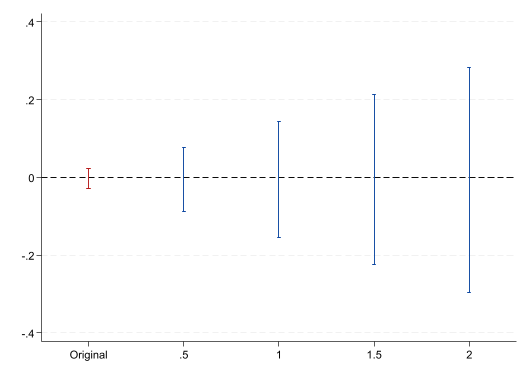

In [11]:
* 安装(以官方 README 为准)
cap which honestdid
if _rc {
    cap net install honestdid, ///
        from("https://raw.githubusercontent.com/mcaceresb/stata-honestdid/main") replace
}

use https://friosavila.github.io/playingwithstata/drdid/mpdta.dta, clear

* 先用 csdid 得到事件研究估计(honestdid 可直接读取 csdid 结果)
qui csdid lemp lpop, ivar(countyreal) time(year) gvar(first_treat) ///
     method(dripw) agg(event)

* 敏感性分析：Mbar 取 0.5、1、1.5、2
* Mbar = 允许的政策后趋势偏离相对于政策前最大偏离的倍数
capture noisily honestdid, pre(1/3) post(4/6) mvec(0.5(0.5)2) coefplot
if _rc di as error "honestdid 未运行成功，请见 GitHub README 核对安装与语法。"


**输出怎么读**：`honestdid` 给出在不同「允许趋势偏离幅度」（`mvec`/Mbar）下，处理效应的稳健置信区间。核心看**breakdown 值**——趋势偏离达到多大时，置信区间才开始包含 0（结论翻转）。breakdown 值越大，结论对平行趋势违反越不敏感、越可信。

- `pre()` `post()`：指定政策前、政策后的相对期位置（随 csdid 事件结果的排列而定，需按实际输出调整）。
- `mvec(0.5(0.5)2)`：让允许的偏离从政策前最大偏离的 0.5 倍扫到 2 倍。

这把「平行趋势成立吗」这个无法回答的是非题，换成了「结论对假设违反有多敏感」这个可量化的问题。

**对口文献（含复现资料）**

- Rambachan, A., & Roth, J. (2023). A more credible approach to parallel trends. *Review of Economic Studies*, 90(5), 2555–2591. honest DiD 的原始文献，配套 R 包 `HonestDiD` 与 Stata 版 `honestdid`（[github](https://github.com/mcaceresb/stata-honestdid)），复现示例直接对接事件研究输出。审稿人越来越常要求这类敏感性分析，该文是标准范本。


## 多估计量同框对比图（可选模块）

把 TWFE、`csdid`、Sun–Abraham 的动态效应画在同一张图，直观展示不同估计量的动态路径差异。下面给出可运行的骨架：抓取 `csdid` 事件研究结果、整理成长表、绘图。完整的多估计量模拟对比可参考 Zevelev 的 [Compare-DiD-Estimators](https://github.com/azev77/Compare-DiD-Estimators)，周嘉怡 ([2023](https://www.lianxh.cn/details/1097.html)) 有中文整理，正文「各估计量放在一起比一比」一节的两张图即出自该材料。

(Written by R.              )
............
Difference-in-difference with Multiple Time Periods

                                                         Number of obs = 2,500
Outcome model  : least squares
Treatment model: inverse probability
------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |     -0.000      0.008    -0.01   0.995       -0.015       0.015
    Post_avg |     -0.080      0.019    -4.24   0.000       -0.118      -0.043
         Tm3 |      0.027      0.014     1.90   0.057       -0.001       0.054
         Tm2 |     -0.004      0.013    -0.28   0.780       -0.029       0.022
         Tm1 |     -0.023      0.014    -1.60   0.109       -0.052       0.005
         Tp0 |     -0.021      0.011    -1.83   0.067       -0.044       0.001
         Tp1 |     -0.053      0.016    -3.24 

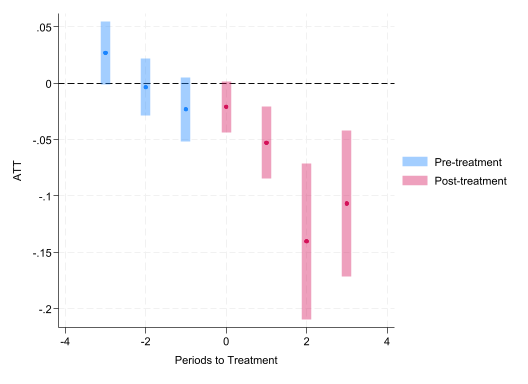

In [ ]:
use https://friosavila.github.io/playingwithstata/drdid/mpdta.dta, clear

csdid lemp lpop, ivar(countyreal) time(year) gvar(first_treat) ///
     method(dripw) agg(event)
     
csdid_plot

* 多估计量同框思路：
*  1. 分别运行 csdid / eventstudyinteract / twfe，各自取出 event_time、coef、se；
*  2. 拼成长表(event_time coef lb ub method)；
*  3. twoway (rcap lb ub event_time) (connected coef event_time), by(method)
di as text "多估计量同框图：按上述三步在本地整理后绘制。"


**这张图想说明什么**：不同估计量在同一数据上给出的动态路径，**形状应大体一致**（都指向同方向的效应演化），但**具体数值和置信区间会有差异**，因为它们的目标参数与加权方式不同。图上若三条线走势一致，就是「结论不依赖单一估计量」最有力的可视化证据。

## 方法与软件地图

正文不把命令写成教程；课后系统查阅优先看这些资源：

- **Asjad Naqvi, DiD 方法与软件地图**：<https://asjadnaqvi.github.io/DiD/> —— 跟踪各语言 DID 包的发展，列出 TWFE、Bacon、`csdid`、`did_imputation`、`eventstudyinteract`、`did2s`、`stackedev`、`jwdid`、`did_multiplegt_dyn`、`sdid` 等全部入口。
- **Pedro Sant'Anna, DiD Resources**：<https://psantanna.com/did-resources/> —— 理论与课程索引，含 JEL practitioner guide、DID 课程、checklist，并说明各命令适用场景。
- **Fernando Rios-Avila, stpackages**（`csdid` / `drdid` 的作者仓库与文档）：<https://github.com/friosavila/stpackages>
- **Albert Alex Zevelev, Compare-DiD-Estimators**（多估计量模拟对比）：<https://github.com/azev77/Compare-DiD-Estimators>
- **Kyle Butts**, `did2s`（Stata 版）：<https://github.com/kylebutts/did2s_stata>
- **Stata** `honestdid`：<https://github.com/mcaceresb/stata-honestdid>

**延伸阅读（含复现包）**：

- Cengiz, Dube, Lindner & Zipperer (2019, QJE)，最低工资的堆叠事件研究，交错处理的应用典范。复现包（数据 + 代码）见 Harvard Dataverse：<https://doi.org/10.7910/DVN/TJCTC7>。
- Callaway & Sant'Anna (2021, J. Econometrics)，group-time ATT 的原始文献，`csdid`/`did` 的理论出处，配套 R 包 `did` 与本附录数据 `mpdta`。
- Liu, D. (2023). Heterogeneous Difference-in-Differences in Stata. Stata Webinar slides（正文最低工资案例与四类聚合公式的原始材料）：<https://www.stata.com/training/webinar_series/materials/hdidweb1.pdf>。
